### aim: 

### date: 

In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [3]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


In [4]:
#kostelec - polsko
kostelec_6 = ['#C94B3C', '#E47A5C', '#A8B89C', '#6B9B7D', '#7FA4B8', '#4A3830']
kostelec_12 = ['#B23D32', '#C94B3C', '#E47A5C', '#D89B7A', '#E5C9A8', '#C8D4B8', '#A8B89C', '#6B9B7D', '#7FA4B8', '#5B7A8C', '#4A3830', '#2A1F1A']

#prachov - jezero 
prachovjezero_6 = ['#E85A2A', '#F4A63D', '#6B8C3E', '#5B9BAD', '#4A6B8A', '#6B3428']
prachovjezero_12 = ['#D84B28', '#E85A2A', '#F27435', '#F4A63D', '#D4B665', '#89A648', '#6B8C3E', '#4E7054', '#5B9BAD', '#4A6B8A', '#6B3428', '#3D2820']

# Tatry 
tatry_6 = ['#9B7850', '#D4C8A8', '#5B7F68', '#7BA6BC', '#A8BECF', '#3A4F3C']
tatry_12 = ['#7A5F40', '#9B7850', '#C4B090', '#E5D8B8', '#B8D090', '#8FAB80', '#5B7F68', '#5B7B7C', '#7BA6BC', '#A8BECF', '#3A4F3C', '#2B3A2E']
#cesky raj
ceskyraj_6 = ['#B8734E', '#D4A562', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#3A2F28']
ceskyraj_12 = ['#A85C3C', '#B8734E', '#D49558', '#D4A562', '#E5C485', '#9CB68A', '#6B8B72', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#5B3F4A', '#3A2F28']

## prachov - skaly
prachovskaly_6 = ['#B8844E', '#D4A865', '#6B8B5C', '#4B7B8C', '#2B5B8C', '#1B3F5C']
prachovskaly_12 = ['#9B6B3C', '#B8844E', '#C89B5A', '#D4A865', '#E5C68A', '#8BA872', '#6B8B5C', '#4B6B5A', '#5B8B9C', '#4B7B8C', '#2B5B8C', '#1B3F5C']

## jested lanovka
jested_6 = ['#D86B45', '#D4B870', '#8FAB7C', '#5B7B8C', '#6B8BAC', '#3A5B48']
jested_12 = ['#C85B3A', '#D86B45', '#E59B58', '#D4B870', '#E5D090', '#B8C88C', '#8FAB7C', '#6B8B78', '#5B7B8C', '#6B8BAC', '#4B6B5C', '#3A5B48']

## krkonose 
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
krkonose_12 = ['#B87A3C', '#E5A542', '#F5C855', '#D4DB6A', '#C4D858', '#A8C850', '#6B8B5C', '#5B7B6C', '#4B6B8C', '#7A9BAC', '#8B6B47', '#5B4B38']

## dumbier
dumbier_6 = ['#D87845', '#E5C8A0', '#4B7BC2', '#6B9BD8', '#7AB8E5', '#1A2B3A']
dumbier_12 = ['#C86838', '#D87845', '#E59B68', '#E5C8A0', '#F5E8D0', '#A8C8E5', '#7AB8E5', '#6B9BD8', '#4B7BC2', '#3A5B8C', '#2A3B5C', '#1A2B3A']

## assorted snippets

#### notebook footer

In [5]:
def nbf(fig, notebook_name, path_y_position=0.02):
    """
    Add notebook path as footer to figure with automatic spacing.
    
    Parameters:
    -----------
    fig : matplotlib figure object
    notebook_name : str
        Name of the notebook file (e.g., 'AMOCts.ipynb')
    path_y_position : float
        Y position for the footer text (default 0.02 = 2% from bottom)
        
    usage 
    bottom_margin = add_notebook_footer(fig, 'AMOCts.ipynb')
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])    
    """
    notebook_path = os.path.abspath(os.getcwd())
    full_notebook_path = os.path.join(notebook_path, notebook_name)
    fig.text(0.5, path_y_position, f'Notebook: {full_notebook_path}', ha='center', 
             fontsize=10, style='italic', color='gray')
    
    # Return the bottom margin needed for tight_layout
    return path_y_position + 0.05  # Add buffer above text

## load climatologies

    - note that climatologies are made in get_clim.py
    - integration/etc can be made in workhorse-integrate-etc
    - regridding is in regrid_clim.sh

In [6]:
CCLIM = 'TOM12_TJ_LC51'
HIST = 'TOM12_TJ_LA50'
HOSE = 'TOM12_TJ_LAH3'

runs = ['TOM12_TJ_LC51', 'TOM12_TJ_LA50', 'TOM12_TJ_LAH3']
ds_cclim, ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc') 
                                for run in runs]

vars_phy = [
 'DIA',
 'MIX',
 'COC',
 'PIC',
 'PHA',
 'FIX']
vars_zoo =  [
 'BAC',
 'PRO',
 'PTE',
 'MES',
 'GEL',
 'MAC' ] 

## figure_shift_phy

In [7]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import numpy as np
# import cmocean.cm as cm
# import xarray as xr
# from matplotlib.colors import LogNorm

# # ============ EDITABLE PARAMETERS ============
# # Adjustable font sizes
# title_fontsize = 20
# label_fontsize = 20

# # Absolute colorbar limits
# vmin_abs = 1e-6   # For log scale minimum (left column)
# vmax_abs = 5e-4   # For log scale maximum (left column)
# abs_max_diff = 1e-4  # For difference plots (middle and right columns)

# # Colorbar aspect ratio (higher = thinner)
# cbar_aspect = 30

# # Layout spacing
# hspace = 0.02  # Vertical space between rows (reduced)
# wspace = 0.05   # Horizontal space between columns (reduced)
# # ============================================

# # Load datasets
# runs = ['TOM12_TJ_LC51', 'TOM12_TJ_LA50', 'TOM12_TJ_LAH3']
# ds_cclim, ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc') 
#                                 for run in runs]

# tvars = vars_phy 
# # Create figure with subplots using PlateCarree projection
# fig, axes = plt.subplots(6, 3, figsize=(15, 16), 
#                          subplot_kw={'projection': ccrs.PlateCarree()})

# # Data projection
# data_crs = ccrs.PlateCarree()

# # Create land feature for masking
# land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
#                                      edgecolor='none',
#                                      facecolor='lightgrey')

# # Column titles (only on first row)
# col_titles = ['CCLIM', 'CCLIM - HIST', 'CCLIM - HOSE']

# for i, var in enumerate(tvars):
#     # Left column: ds_cclim (time-averaged) with log scale
#     ax = axes[i, 0]
#     data_cclim = ds_cclim[var].mean(dim='time')
#     im1 = data_cclim.plot.pcolormesh(ax=ax, transform=data_crs,
#                               cmap=cm.haline, 
#                               norm=LogNorm(vmin=vmin_abs, vmax=vmax_abs),
#                               add_colorbar=False)
#     ax.add_feature(land, zorder=2)
#     ax.coastlines()
#     ax.set_global()
#     if i == 0:
#         ax.set_title(col_titles[0], fontsize=title_fontsize, fontweight='bold')
#     else:
#         ax.set_title('')
    
#     # Add variable label on the left
#     ax.text(-0.025, 0.5, var, transform=ax.transAxes, 
#             fontsize=label_fontsize, fontweight='bold',
#             rotation=90, va='center', ha='center')
    
#     # Calculate differences
#     diff_hist = ds_cclim[var].mean(dim='time') - ds_hist[var].mean(dim='time')
#     diff_hose = ds_cclim[var].mean(dim='time') - ds_hose[var].mean(dim='time')
    
#     # Middle column: ds_cclim - ds_hist (time-averaged)
#     ax = axes[i, 1]
#     im2 = diff_hist.plot.pcolormesh(ax=ax, transform=data_crs,
#                          cmap='RdBu_r', 
#                          vmin=-abs_max_diff, vmax=abs_max_diff,
#                          add_colorbar=False)
#     ax.add_feature(land, zorder=2)
#     ax.coastlines()
#     ax.set_global()
#     if i == 0:
#         ax.set_title(col_titles[1], fontsize=title_fontsize, fontweight='bold')
#     else:
#         ax.set_title('')
    
#     # Right column: ds_cclim - ds_hose (time-averaged)
#     ax = axes[i, 2]
#     im3 = diff_hose.plot.pcolormesh(ax=ax, transform=data_crs,
#                          cmap='RdBu_r', 
#                          vmin=-abs_max_diff, vmax=abs_max_diff,
#                          add_colorbar=False)
#     ax.add_feature(land, zorder=2)
#     ax.coastlines()
#     ax.set_global()
#     if i == 0:
#         ax.set_title(col_titles[2], fontsize=title_fontsize, fontweight='bold')
#     else:
#         ax.set_title('')

# # Tighten layout to reduce whitespace
# plt.subplots_adjust(hspace=hspace, wspace=wspace, left=0.05, right=0.95, top=0.98, bottom=0.08)

# # Add colorbars at the bottom, stacked vertically and centered
# # Create axes for colorbars
# cbar_width = 0.55  # Width of each colorbar
# cbar_height = 0.015  # Height of each colorbar
# cbar_left = (1 - cbar_width) / 2  # Center the colorbars

# # Colorbar for left column (absolute values)
# cax1 = fig.add_axes([cbar_left, 0.065, cbar_width, cbar_height])
# cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
# cbar1.set_label('Concentration (mol/m2)', fontsize=label_fontsize)

# # Colorbar for middle and right columns (differences)
# cax2 = fig.add_axes([cbar_left, 0.01, cbar_width, cbar_height])
# cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
# cbar2.set_label('Difference (mol/m2)', fontsize=label_fontsize)

# nbf(fig, 'AMOC-PLANKTOM/AMOC-LoP-202510/Fig-shift.ipynb', path_y_position=-0.055)
# plt.savefig('./plts/Fig_phyto_shift.jpg', dpi=300, bbox_inches='tight')
# plt.show()

## zooplankton

In [8]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import numpy as np
# import cmocean.cm as cm
# import xarray as xr
# from matplotlib.colors import LogNorm

# # ============ EDITABLE PARAMETERS ============
# # Adjustable font sizes
# title_fontsize = 20
# label_fontsize = 20

# # Absolute colorbar limits
# vmin_abs = 1e-6   # For log scale minimum (left column)
# vmax_abs = 5e-4   # For log scale maximum (left column)
# abs_max_diff = 1e-4  # For difference plots (middle and right columns)

# # Colorbar aspect ratio (higher = thinner)
# cbar_aspect = 30

# # Layout spacing
# hspace = 0.02  # Vertical space between rows (reduced)
# wspace = 0.05   # Horizontal space between columns (reduced)
# # ============================================

# # Load datasets
# runs = ['TOM12_TJ_LC51', 'TOM12_TJ_LA50', 'TOM12_TJ_LAH3']
# ds_cclim, ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/software/runs/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc') 
#                                 for run in runs]

# tvars = vars_zoo 
# # Create figure with subplots using PlateCarree projection
# fig, axes = plt.subplots(6, 3, figsize=(15, 16), 
#                          subplot_kw={'projection': ccrs.PlateCarree()})

# # Data projection
# data_crs = ccrs.PlateCarree()

# # Create land feature for masking
# land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
#                                      edgecolor='none',
#                                      facecolor='lightgrey')

# # Column titles (only on first row)
# col_titles = ['CCLIM', 'CCLIM - HIST', 'CCLIM - HOSE']

# for i, var in enumerate(tvars):
#     # Left column: ds_cclim (time-averaged) with log scale
#     ax = axes[i, 0]
#     data_cclim = ds_cclim[var].mean(dim='time')
#     im1 = data_cclim.plot.pcolormesh(ax=ax, transform=data_crs,
#                               cmap=cm.haline, 
#                               norm=LogNorm(vmin=vmin_abs, vmax=vmax_abs),
#                               add_colorbar=False)
#     ax.add_feature(land, zorder=2)
#     ax.coastlines()
#     ax.set_global()
#     if i == 0:
#         ax.set_title(col_titles[0], fontsize=title_fontsize, fontweight='bold')
#     else:
#         ax.set_title('')
    
#     # Add variable label on the left
#     ax.text(-0.025, 0.5, var, transform=ax.transAxes, 
#             fontsize=label_fontsize, fontweight='bold',
#             rotation=90, va='center', ha='center')
    
#     # Calculate differences
#     diff_hist = ds_cclim[var].mean(dim='time') - ds_hist[var].mean(dim='time')
#     diff_hose = ds_cclim[var].mean(dim='time') - ds_hose[var].mean(dim='time')
    
#     # Middle column: ds_cclim - ds_hist (time-averaged)
#     ax = axes[i, 1]
#     im2 = diff_hist.plot.pcolormesh(ax=ax, transform=data_crs,
#                          cmap='RdBu_r', 
#                          vmin=-abs_max_diff, vmax=abs_max_diff,
#                          add_colorbar=False)
#     ax.add_feature(land, zorder=2)
#     ax.coastlines()
#     ax.set_global()
#     if i == 0:
#         ax.set_title(col_titles[1], fontsize=title_fontsize, fontweight='bold')
#     else:
#         ax.set_title('')
    
#     # Right column: ds_cclim - ds_hose (time-averaged)
#     ax = axes[i, 2]
#     im3 = diff_hose.plot.pcolormesh(ax=ax, transform=data_crs,
#                          cmap='RdBu_r', 
#                          vmin=-abs_max_diff, vmax=abs_max_diff,
#                          add_colorbar=False)
#     ax.add_feature(land, zorder=2)
#     ax.coastlines()
#     ax.set_global()
#     if i == 0:
#         ax.set_title(col_titles[2], fontsize=title_fontsize, fontweight='bold')
#     else:
#         ax.set_title('')

# # Tighten layout to reduce whitespace
# plt.subplots_adjust(hspace=hspace, wspace=wspace, left=0.05, right=0.95, top=0.98, bottom=0.08)

# # Add colorbars at the bottom, stacked vertically and centered
# # Create axes for colorbars
# cbar_width = 0.55  # Width of each colorbar
# cbar_height = 0.015  # Height of each colorbar
# cbar_left = (1 - cbar_width) / 2  # Center the colorbars

# # Colorbar for left column (absolute values)
# cax1 = fig.add_axes([cbar_left, 0.065, cbar_width, cbar_height])
# cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
# cbar1.set_label('Concentration (mol/m2)', fontsize=label_fontsize)

# # Colorbar for middle and right columns (differences)
# cax2 = fig.add_axes([cbar_left, 0.01, cbar_width, cbar_height])
# cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
# cbar2.set_label('Difference (mol/m2)', fontsize=label_fontsize)

# nbf(fig, 'AMOC-PLANKTOM/AMOC-LoP-202510/Fig-shift.ipynb', path_y_position=-0.055)
# plt.savefig('./plts/Fig_zoo_shift.jpg', dpi=300, bbox_inches='tight')
# plt.show()

# subtract: HIST - CCLIM, HIST-HOSE

### phyto and zoo

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


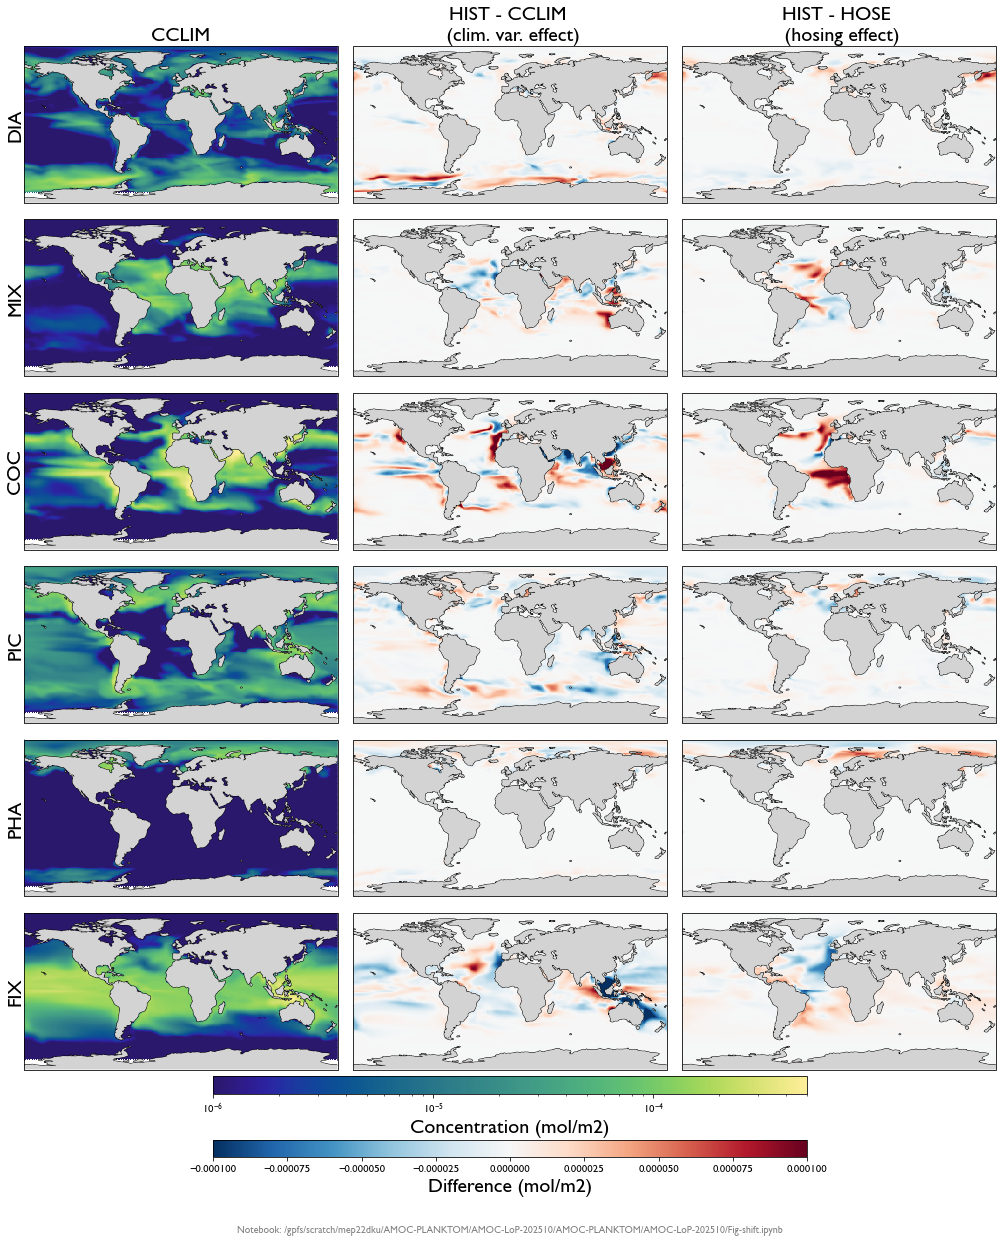

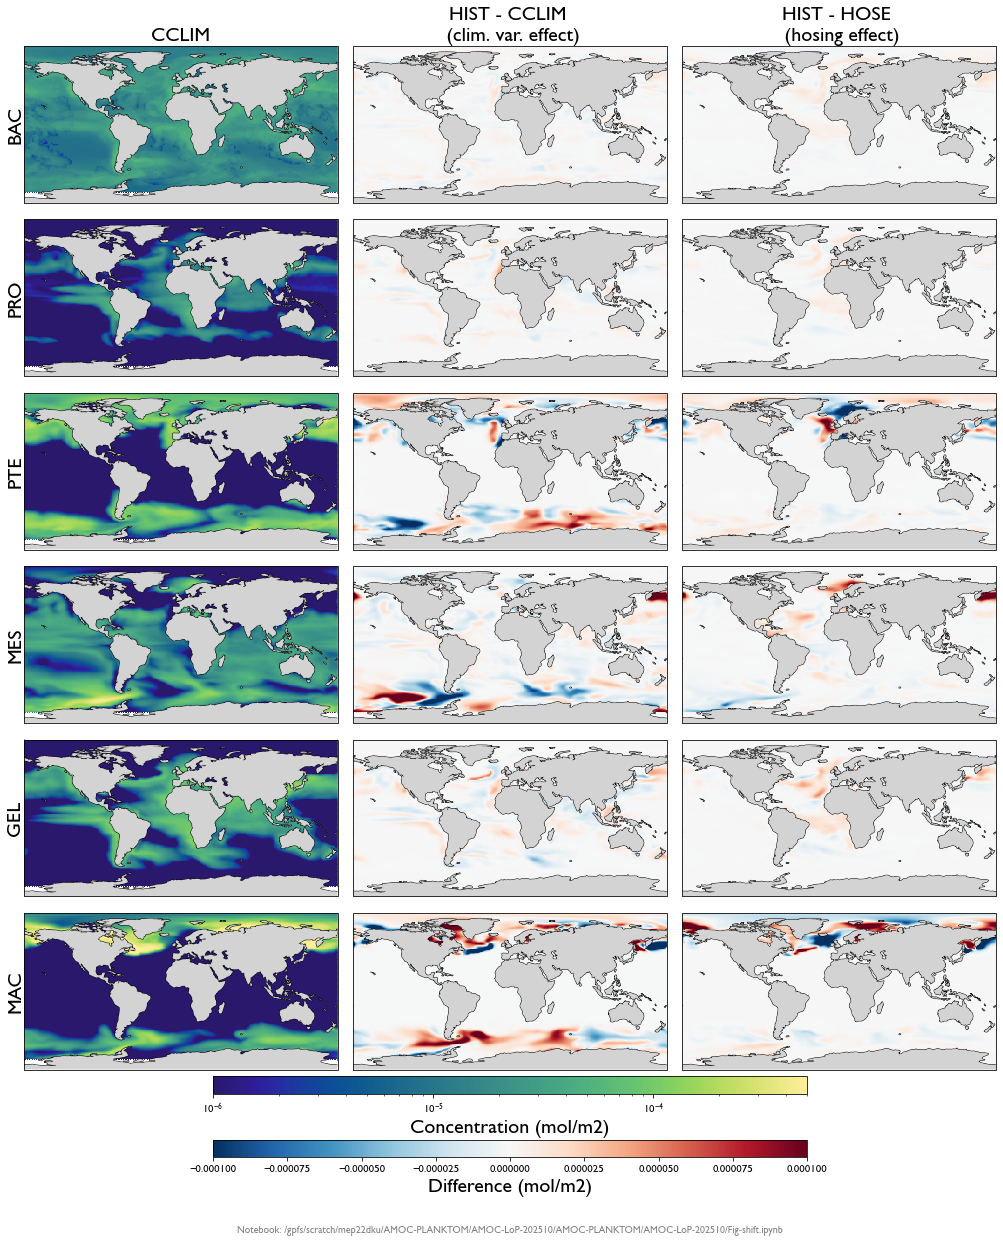

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr
from matplotlib.colors import LogNorm

# ============ EDITABLE PARAMETERS ============
# Adjustable font sizes
title_fontsize = 20
label_fontsize = 20

# Absolute colorbar limits
vmin_abs = 1e-6   # For log scale minimum (left column)
vmax_abs = 5e-4   # For log scale maximum (left column)
abs_max_diff = 1e-4  # For difference plots (middle and right columns)

# Colorbar aspect ratio (higher = thinner)
cbar_aspect = 30

# Layout spacing
hspace = 0.02  # Vertical space between rows (reduced)
wspace = 0.05   # Horizontal space between columns (reduced)
# ============================================

# Load datasets
runs = ['TOM12_TJ_LC51', 'TOM12_TJ_LA50', 'TOM12_TJ_LAH3']
ds_cclim, ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc') 
                                for run in runs]

tvars = vars_phy 
# Create figure with subplots using PlateCarree projection
fig, axes = plt.subplots(6, 3, figsize=(15, 16), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Data projection
data_crs = ccrs.PlateCarree()

# Create land feature for masking
land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                     edgecolor='none',
                                     facecolor='lightgrey')

# Column titles (only on first row)
col_titles = ['CCLIM', 'HIST - CCLIM \n (clim. var. effect)', 'HIST - HOSE \n (hosing effect)']

for i, var in enumerate(tvars):
    # Left column: ds_cclim (time-averaged) with log scale
    ax = axes[i, 0]
    data_cclim = ds_cclim[var].mean(dim='time')
    im1 = data_cclim.plot.pcolormesh(ax=ax, transform=data_crs,
                              cmap=cm.haline, 
                              norm=LogNorm(vmin=vmin_abs, vmax=vmax_abs),
                              add_colorbar=False)
    ax.add_feature(land, zorder=2)
    ax.coastlines()
    ax.set_global()
    if i == 0:
        ax.set_title(col_titles[0], fontsize=title_fontsize, fontweight='bold')
    else:
        ax.set_title('')
    
    # Add variable label on the left
    ax.text(-0.025, 0.5, var, transform=ax.transAxes, 
            fontsize=label_fontsize, fontweight='bold',
            rotation=90, va='center', ha='center')
    
    # Calculate differences
    diff_hist = ds_hist[var].mean(dim='time') - ds_cclim[var].mean(dim='time') 
    diff_hose = ds_hist[var].mean(dim='time') - ds_hose[var].mean(dim='time')
    
    # Middle column: ds_cclim - ds_hist (time-averaged)
    ax = axes[i, 1]
    im2 = diff_hist.plot.pcolormesh(ax=ax, transform=data_crs,
                         cmap='RdBu_r', 
                         vmin=-abs_max_diff, vmax=abs_max_diff,
                         add_colorbar=False)
    ax.add_feature(land, zorder=2)
    ax.coastlines()
    ax.set_global()
    if i == 0:
        ax.set_title(col_titles[1], fontsize=title_fontsize, fontweight='bold')
    else:
        ax.set_title('')
    
    # Right column: ds_cclim - ds_hose (time-averaged)
    ax = axes[i, 2]
    im3 = diff_hose.plot.pcolormesh(ax=ax, transform=data_crs,
                         cmap='RdBu_r', 
                         vmin=-abs_max_diff, vmax=abs_max_diff,
                         add_colorbar=False)
    ax.add_feature(land, zorder=2)
    ax.coastlines()
    ax.set_global()
    if i == 0:
        ax.set_title(col_titles[2], fontsize=title_fontsize, fontweight='bold')
    else:
        ax.set_title('')

# Tighten layout to reduce whitespace
plt.subplots_adjust(hspace=hspace, wspace=wspace, left=0.05, right=0.95, top=0.98, bottom=0.08)

# Add colorbars at the bottom, stacked vertically and centered
# Create axes for colorbars
cbar_width = 0.55  # Width of each colorbar
cbar_height = 0.015  # Height of each colorbar
cbar_left = (1 - cbar_width) / 2  # Center the colorbars

# Colorbar for left column (absolute values)
cax1 = fig.add_axes([cbar_left, 0.065, cbar_width, cbar_height])
cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.set_label('Concentration (mol/m2)', fontsize=label_fontsize)

# Colorbar for middle and right columns (differences)
cax2 = fig.add_axes([cbar_left, 0.01, cbar_width, cbar_height])
cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.set_label('Difference (mol/m2)', fontsize=label_fontsize)

nbf(fig, 'AMOC-PLANKTOM/AMOC-LoP-202510/Fig-shift.ipynb', path_y_position=-0.055)
plt.savefig('./plts/Fig_phyto_shift.jpg', dpi=300, bbox_inches='tight')
plt.show()


tvars = vars_zoo 
# Create figure with subplots using PlateCarree projection
fig, axes = plt.subplots(6, 3, figsize=(15, 16), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Data projection
data_crs = ccrs.PlateCarree()

# Create land feature for masking
land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                     edgecolor='none',
                                     facecolor='lightgrey')

# Column titles (only on first row)
col_titles = ['CCLIM', 'HIST - CCLIM \n (clim. var. effect)', 'HIST - HOSE \n (hosing effect)']

for i, var in enumerate(tvars):
    # Left column: ds_cclim (time-averaged) with log scale
    ax = axes[i, 0]
    data_cclim = ds_cclim[var].mean(dim='time')
    im1 = data_cclim.plot.pcolormesh(ax=ax, transform=data_crs,
                              cmap=cm.haline, 
                              norm=LogNorm(vmin=vmin_abs, vmax=vmax_abs),
                              add_colorbar=False)
    ax.add_feature(land, zorder=2)
    ax.coastlines()
    ax.set_global()
    if i == 0:
        ax.set_title(col_titles[0], fontsize=title_fontsize, fontweight='bold')
    else:
        ax.set_title('')
    
    # Add variable label on the left
    ax.text(-0.025, 0.5, var, transform=ax.transAxes, 
            fontsize=label_fontsize, fontweight='bold',
            rotation=90, va='center', ha='center')
    
    # Calculate differences
    diff_hist = ds_hist[var].mean(dim='time') - ds_cclim[var].mean(dim='time') 
    diff_hose = ds_hist[var].mean(dim='time') - ds_hose[var].mean(dim='time')
    
    # Middle column: ds_cclim - ds_hist (time-averaged)
    ax = axes[i, 1]
    im2 = diff_hist.plot.pcolormesh(ax=ax, transform=data_crs,
                         cmap='RdBu_r', 
                         vmin=-abs_max_diff, vmax=abs_max_diff,
                         add_colorbar=False)
    ax.add_feature(land, zorder=2)
    ax.coastlines()
    ax.set_global()
    if i == 0:
        ax.set_title(col_titles[1], fontsize=title_fontsize, fontweight='bold')
    else:
        ax.set_title('')
    
    # Right column: ds_cclim - ds_hose (time-averaged)
    ax = axes[i, 2]
    im3 = diff_hose.plot.pcolormesh(ax=ax, transform=data_crs,
                         cmap='RdBu_r', 
                         vmin=-abs_max_diff, vmax=abs_max_diff,
                         add_colorbar=False)
    ax.add_feature(land, zorder=2)
    ax.coastlines()
    ax.set_global()
    if i == 0:
        ax.set_title(col_titles[2], fontsize=title_fontsize, fontweight='bold')
    else:
        ax.set_title('')

# Tighten layout to reduce whitespace
plt.subplots_adjust(hspace=hspace, wspace=wspace, left=0.05, right=0.95, top=0.98, bottom=0.08)

# Add colorbars at the bottom, stacked vertically and centered
# Create axes for colorbars
cbar_width = 0.55  # Width of each colorbar
cbar_height = 0.015  # Height of each colorbar
cbar_left = (1 - cbar_width) / 2  # Center the colorbars

# Colorbar for left column (absolute values)
cax1 = fig.add_axes([cbar_left, 0.065, cbar_width, cbar_height])
cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.set_label('Concentration (mol/m2)', fontsize=label_fontsize)

# Colorbar for middle and right columns (differences)
cax2 = fig.add_axes([cbar_left, 0.01, cbar_width, cbar_height])
cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.set_label('Difference (mol/m2)', fontsize=label_fontsize)

nbf(fig, 'AMOC-PLANKTOM/AMOC-LoP-202510/Fig-shift.ipynb', path_y_position=-0.055)
plt.savefig('./plts/Fig_zoo_shift.jpg', dpi=300, bbox_inches='tight')
plt.show()

### get shift-metrics

Processing CCLIM - phytoplankton...
  Saved to data/CCLIM_phytoplankton_province_means.csv
Processing HIST - phytoplankton...
  Saved to data/HIST_phytoplankton_province_means.csv
Processing HOSE - phytoplankton...
  Saved to data/HOSE_phytoplankton_province_means.csv
Processing CCLIM - zooplankton...
  Saved to data/CCLIM_zooplankton_province_means.csv
Processing HIST - zooplankton...
  Saved to data/HIST_zooplankton_province_means.csv
Processing HOSE - zooplankton...
  Saved to data/HOSE_zooplankton_province_means.csv
Colorbar range: 1.00e-07 to 1.00e-04
Saved combined heatmap to data/heatmap_all_provinces.png


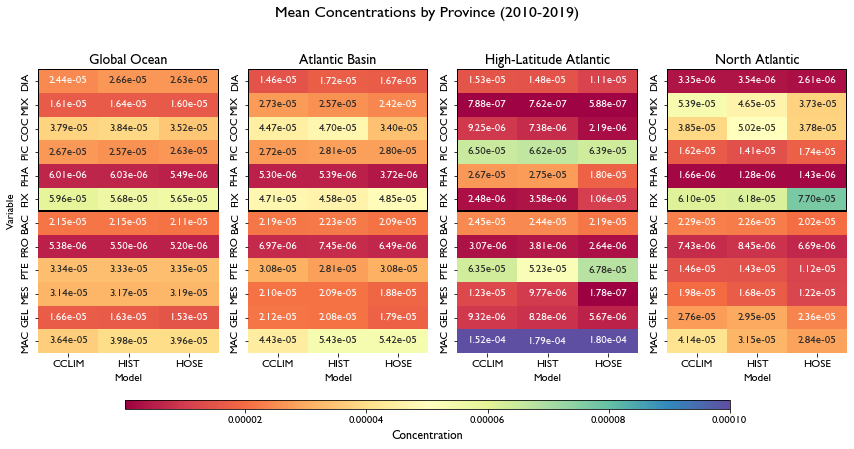


All DataFrames:
   variable province         value  model
0       DIA       GO  2.437903e-05  CCLIM
1       DIA       AB  1.459603e-05  CCLIM
2       DIA       HA  1.531535e-05  CCLIM
3       DIA       NA  3.354767e-06  CCLIM
4       MIX       GO  1.614922e-05  CCLIM
5       MIX       AB  2.727539e-05  CCLIM
6       MIX       HA  7.875993e-07  CCLIM
7       MIX       NA  5.391002e-05  CCLIM
8       COC       GO  3.794258e-05  CCLIM
9       COC       AB  4.467501e-05  CCLIM
10      COC       HA  9.247533e-06  CCLIM
11      COC       NA  3.846210e-05  CCLIM
12      PIC       GO  2.671957e-05  CCLIM
13      PIC       AB  2.721108e-05  CCLIM
14      PIC       HA  6.501811e-05  CCLIM
15      PIC       NA  1.621325e-05  CCLIM
16      PHA       GO  6.005874e-06  CCLIM
17      PHA       AB  5.304832e-06  CCLIM
18      PHA       HA  2.671486e-05  CCLIM
19      PHA       NA  1.660170e-06  CCLIM


In [10]:
# Setup
runs = ['TOM12_TJ_LC51', 'TOM12_TJ_LA50', 'TOM12_TJ_LAH3']
run_names = ['CCLIM', 'HIST', 'HOSE']

# Load datasets
ds_cclim, ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc') 
                                for run in runs]
datasets = {'CCLIM': ds_cclim, 'HIST': ds_hist, 'HOSE': ds_hose}

# Load masks
MA = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

# Define provinces
provinces = {
    'GO': mask.csize,
    'AB': mask.csize * MA.AB,
    'HA': mask.csize * MA.HA,
    'NA': mask.csize * MA.NA
}

# Define variables
vars_phy = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
vars_zoo = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC']

# Create output directory
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)

# Function to calculate province means
def calculate_province_means(ds, variables, provinces):
    """Calculate spatial means over provinces for given variables"""
    results = []
    
    # Average over time dimension first
    ds_mean = ds.mean(dim='time')
    
    for var in variables:
        if var not in ds_mean:
            print(f"Warning: {var} not found in dataset")
            continue
            
        var_data = ds_mean[var]
        
        for prov_name, prov_mask in provinces.items():
            masked_data = var_data.where(prov_mask > 0)
            spatial_dims = [d for d in masked_data.dims if d not in ['time_counter', 'time']]
            prov_mean = float(masked_data.mean(dim=spatial_dims).values)
            
            results.append({
                'variable': var,
                'province': prov_name,
                'value': prov_mean
            })
    
    return pd.DataFrame(results)

# Calculate for each model and variable group
all_results = {}

for var_group, var_list in [('phytoplankton', vars_phy), ('zooplankton', vars_zoo)]:
    for model_name, ds in datasets.items():
        print(f"Processing {model_name} - {var_group}...")
        df = calculate_province_means(ds, var_list, provinces)
        df['model'] = model_name
        all_results[f'{model_name}_{var_group}'] = df
        
        # Save individual DataFrames
        output_file = output_dir / f'{model_name}_{var_group}_province_means.csv'
        df.to_csv(output_file, index=False)
        print(f"  Saved to {output_file}")

# Combine all results
df_all = pd.concat(all_results.values(), ignore_index=True)
df_all.to_csv(output_dir / 'all_province_means.csv', index=False)

# Create single figure with 4 subplots (one for each province)
provinces_list = ['GO', 'AB', 'HA', 'NA']
province_names = {
    'GO': 'Global Ocean',
    'AB': 'Atlantic Basin',
    'HA': 'High-Latitude Atlantic',
    'NA': 'North Atlantic'
}

fig, axes = plt.subplots(1, 4, figsize=(12, 6))

# First pass: get min/max values for shared colormap
all_pivots = []
for province in provinces_list:
    df_prov = df_all[df_all['province'] == province].copy()
    pivot = df_prov.pivot(index='variable', columns='model', values='value')
    pivot = pivot[['CCLIM', 'HIST', 'HOSE']]
    all_vars = vars_phy + vars_zoo
    pivot = pivot.reindex([v for v in all_vars if v in pivot.index])
    all_pivots.append(pivot)

# Get global min/max for shared colormap
vmin_calc = min(p.min().min() for p in all_pivots)
vmax_calc = max(p.max().max() for p in all_pivots)

# ADJUSTABLE: Set colorbar limits (comment out to use full range)
# Option 1: Use percentiles to exclude outliers
# all_values = pd.concat([p.stack() for p in all_pivots])
# vmin = all_values.quantile(0.05)
# vmax = all_values.quantile(0.95)

# Option 2: Manually set the limits (uncomment and adjust as needed)
vmin = 1e-7  # Adjust this value
vmax = 1e-4  # Adjust this value

# Option 3: Use full range (uncomment to override manual settings)
# vmin, vmax = vmin_calc, vmax_calc

print(f"Colorbar range: {vmin:.2e} to {vmax:.2e}")

# Second pass: create heatmaps with shared colormap
for idx, (province, pivot) in enumerate(zip(provinces_list, all_pivots)):
    ax = axes[idx]
    
    # Create heatmap without individual colorbars
    sns.heatmap(pivot, annot=True, fmt='.2e', cmap='Spectral', ax=ax, 
                vmin=vmin, vmax=vmax, cbar=False)
    ax.set_title(f'{province_names[province]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model')
    
    # Add box around phytoplankton (first 6 rows)
    from matplotlib.patches import Rectangle
    rect = Rectangle((0, 0), pivot.shape[1], 6, 
                     linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(rect)
    
    # Only show y-label on leftmost plot
    if idx == 0:
        ax.set_ylabel('Variable')
    else:
        ax.set_ylabel('')

# Add single colorbar at the bottom
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='Spectral', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Concentration', fontsize=12)

plt.suptitle('Mean Concentrations by Province (2010-2019)', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])

# Save figure
fig_file = output_dir / 'heatmap_all_provinces.png'
plt.savefig(fig_file, dpi=300, bbox_inches='tight')
print(f"Saved combined heatmap to {fig_file}")
plt.show()

print("\nAll DataFrames:")
print(df_all.head(20))

## diverging differences

Processing CCLIM - phytoplankton...
Processing HIST - phytoplankton...
Processing HOSE - phytoplankton...
Processing CCLIM - zooplankton...
Processing HIST - zooplankton...
Processing HOSE - zooplankton...
Colorbar range: -2.72e-05 to 2.72e-05
Saved difference heatmap to data/heatmap_differences.png


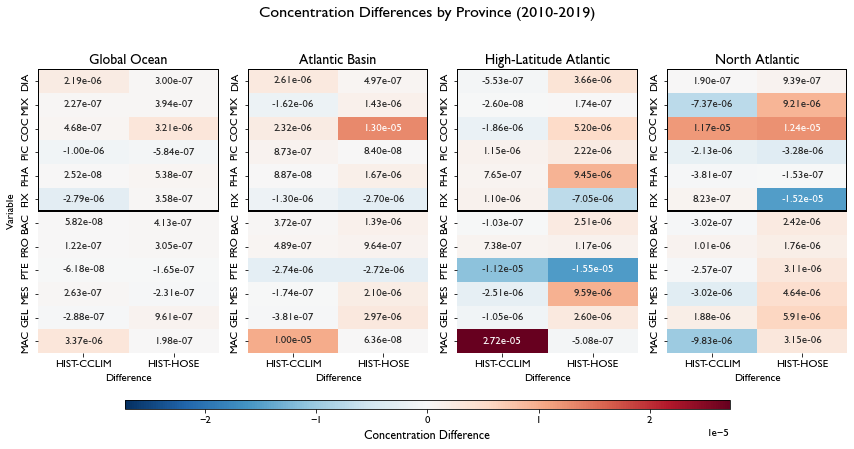

In [11]:

abs_max = 5e-3 
# Setup
runs = ['TOM12_TJ_LC51', 'TOM12_TJ_LA50', 'TOM12_TJ_LAH3']
run_names = ['CCLIM', 'HIST', 'HOSE']

# Load datasets
ds_cclim, ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc') 
                                for run in runs]
datasets = {'CCLIM': ds_cclim, 'HIST': ds_hist, 'HOSE': ds_hose}

# Load masks
MA = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

# Define provinces
provinces = {
    'GO': mask.csize,
    'AB': mask.csize * MA.AB,
    'HA': mask.csize * MA.HA,
    'NA': mask.csize * MA.NA
}

# Define variables
vars_phy = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
vars_zoo = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC']

# Create output directory
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)

# Function to calculate province means
def calculate_province_means(ds, variables, provinces):
    """Calculate spatial means over provinces for given variables"""
    results = []
    
    # Average over time dimension first
    ds_mean = ds.mean(dim='time')
    
    for var in variables:
        if var not in ds_mean:
            print(f"Warning: {var} not found in dataset")
            continue
            
        var_data = ds_mean[var]
        
        for prov_name, prov_mask in provinces.items():
            masked_data = var_data.where(prov_mask > 0)
            spatial_dims = [d for d in masked_data.dims if d not in ['time_counter', 'time']]
            prov_mean = float(masked_data.mean(dim=spatial_dims).values)
            
            results.append({
                'variable': var,
                'province': prov_name,
                'value': prov_mean
            })
    
    return pd.DataFrame(results)

# Calculate for each model and variable group
all_results = {}

for var_group, var_list in [('phytoplankton', vars_phy), ('zooplankton', vars_zoo)]:
    for model_name, ds in datasets.items():
        print(f"Processing {model_name} - {var_group}...")
        df = calculate_province_means(ds, var_list, provinces)
        df['model'] = model_name
        all_results[f'{model_name}_{var_group}'] = df

# Combine all results
df_all = pd.concat(all_results.values(), ignore_index=True)

# Create single figure with 4 subplots (one for each province)
provinces_list = ['GO', 'AB', 'HA', 'NA']
province_names = {
    'GO': 'Global Ocean',
    'AB': 'Atlantic Basin',
    'HA': 'High-Latitude Atlantic',
    'NA': 'North Atlantic'
}

fig, axes = plt.subplots(1, 4, figsize=(12, 6))

# First pass: calculate differences and get min/max for shared colormap
all_diff_pivots = []
for province in provinces_list:
    df_prov = df_all[df_all['province'] == province].copy()
    pivot = df_prov.pivot(index='variable', columns='model', values='value')
    
    # Calculate differences
    diff_pivot = pd.DataFrame()
    diff_pivot['HIST-CCLIM'] = pivot['HIST'] - pivot['CCLIM']
    diff_pivot['HIST-HOSE'] = pivot['HIST'] - pivot['HOSE']
    
    # Reorder rows to have phyto first, then zoo
    all_vars = vars_phy + vars_zoo
    diff_pivot = diff_pivot.reindex([v for v in all_vars if v in diff_pivot.index])
    all_diff_pivots.append(diff_pivot)

# Get global min/max for shared colormap (symmetric around 0)
abs_max = max(abs(p.min().min()) for p in all_diff_pivots)
abs_max = max(abs_max, max(p.max().max() for p in all_diff_pivots))

# ADJUSTABLE: Set colorbar limits (comment out to use full range)
# Use percentile to ignore extreme outliers
vmin_calc = min(p.min().min() for p in all_diff_pivots)
vmax_calc = max(p.max().max() for p in all_diff_pivots)
abs_max = max(abs(vmin_calc), abs(vmax_calc))

# Option 1: Use percentiles to exclude outliers
# all_values = pd.concat([p.stack() for p in all_diff_pivots])
# abs_max = max(abs(all_values.quantile(0.05)), abs(all_values.quantile(0.95)))

# Option 2: Manually set the limit (uncomment and adjust as needed)
 # Adjust this value to zoom in on non-MAC species

vmin, vmax = -abs_max, abs_max

print(f"Colorbar range: {vmin:.2e} to {vmax:.2e}")

# Second pass: create heatmaps with shared colormap
for idx, (province, diff_pivot) in enumerate(zip(provinces_list, all_diff_pivots)):
    ax = axes[idx]
    
    # Create heatmap without individual colorbars (using diverging colormap)
    sns.heatmap(diff_pivot, annot=True, fmt='.2e', cmap='RdBu_r', ax=ax, 
                vmin=vmin, vmax=vmax, cbar=False, center=0)
    ax.set_title(f'{province_names[province]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Difference')
    
    # Add box around phytoplankton (first 6 rows)
    from matplotlib.patches import Rectangle
    rect = Rectangle((0, 0), diff_pivot.shape[1], 6, 
                     linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(rect)
    
    # Only show y-label on leftmost plot
    if idx == 0:
        ax.set_ylabel('Variable')
    else:
        ax.set_ylabel('')

# Add single colorbar at the bottom
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Concentration Difference', fontsize=12)

plt.suptitle('Concentration Differences by Province (2010-2019)', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])

# Save figure
fig_file = output_dir / 'heatmap_differences.png'
plt.savefig(fig_file, dpi=300, bbox_inches='tight')
print(f"Saved difference heatmap to {fig_file}")
plt.show()

## polygons

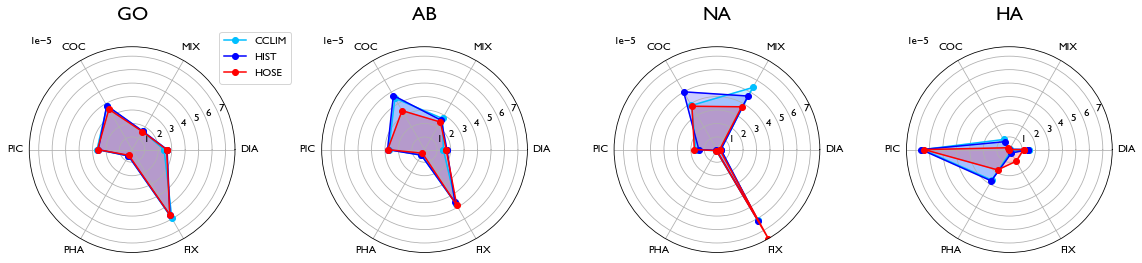

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv('data/all_province_means.csv')  # Use combined file with all models

# Fix NA being read as NaN
df['province'] = df['province'].fillna('NA')

provinces = ['GO', 'AB', 'NA', 'HA']
colors = {'CCLIM': 'deepskyblue', 'HIST': 'b', 'HOSE': 'r'}
models = ['CCLIM', 'HIST', 'HOSE']

# Get global min/max for shared y-axis
df_phy = df[df['variable'].isin(vars_phy)]
vmin, vmax = df_phy['value'].min(), df_phy['value'].max()

fig, axes = plt.subplots(1, 4, subplot_kw=dict(projection='polar'), figsize=(16, 4))

theta = np.linspace(0, 2*np.pi, len(vars_phy), endpoint=False)
theta = np.concatenate([theta, [theta[0]]])  # Close the polygon

for ax, prov in zip(axes, provinces):
    for model in models:
        df_subset = df[(df['model'] == model) & (df['province'] == prov)]
        df_subset = df_subset[df_subset['variable'].isin(vars_phy)]
        
        values = df_subset.set_index('variable').loc[vars_phy, 'value'].values
        values = np.concatenate([values, [values[0]]])  # Close the polygon
        
        ax.plot(theta, values, 'o-', color=colors[model], label=model)
        ax.fill(theta, values, alpha=0.2, color=colors[model])
    
    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(vars_phy)
    ax.set_title(prov, fontsize=20, y=1.1)
    ax.set_ylim(vmin, vmax)
    if prov == 'GO':
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

## looking at climatologies of Cflx, PPINT, EXP

Loading CCLIM...
Loading HIST...
Loading HOSE...
Saved bar plot to data/barplot_diad_provinces.png


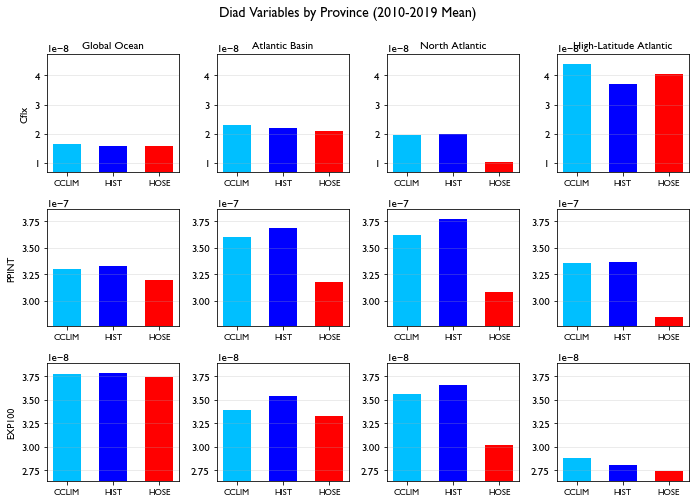


Sample data:
   variable  model province         value
0      Cflx  CCLIM       GO  1.640431e-08
1      Cflx  CCLIM       AB  2.318540e-08
2      Cflx  CCLIM       HA  4.385815e-08
3      Cflx  CCLIM       NA  1.971977e-08
4      Cflx   HIST       GO  1.565761e-08
5      Cflx   HIST       AB  2.195338e-08
6      Cflx   HIST       HA  3.714210e-08
7      Cflx   HIST       NA  1.976369e-08
8      Cflx   HOSE       GO  1.567084e-08
9      Cflx   HOSE       AB  2.110344e-08
10     Cflx   HOSE       HA  4.061964e-08
11     Cflx   HOSE       NA  1.026634e-08
12    PPINT  CCLIM       GO  3.296240e-07
13    PPINT  CCLIM       AB  3.597187e-07
14    PPINT  CCLIM       HA  3.355302e-07


In [13]:
# Setup
runs = ['TOM12_TJ_LC51', 'TOM12_TJ_LA50', 'TOM12_TJ_LAH3']
run_names = ['CCLIM', 'HIST', 'HOSE']
bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'

# Define variables (EXP100 uses EXP as base variable)
variables = ['Cflx', 'PPINT', 'EXP100']
var_mapping = {'Cflx': 'Cflx', 'PPINT': 'PPINT', 'EXP100': 'EXP'}

# Province names
provinces_list = ['GO', 'AB', 'HA', 'NA']
province_names = {
    'GO': 'Global Ocean',
    'AB': 'Atlantic Basin',
    'HA': 'High-Latitude Atlantic',
    'NA': 'North Atlantic'
}

# Create output directory
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)

# Load data for all models and variables
all_data = {}

for model_name, run in zip(run_names, runs):
    print(f"Loading {model_name}...")
    all_data[model_name] = {}
    
    for var in variables:
        filepath = f'{bdir}/{run}/{run}_diad_{var}_dNone_provinces.nc'
        ds = xr.open_dataset(filepath)
        
        # Convert cftime to pandas datetime if needed
        if 'time_counter' in ds.coords:
            try:
                time_pd = pd.to_datetime([pd.Timestamp(t.isoformat()) for t in ds.time_counter.values])
                ds = ds.assign_coords(time_counter=time_pd)
            except:
                pass  # Already in pandas datetime format
        
        # Get the actual variable name (EXP for EXP100, otherwise same as var)
        actual_var = var_mapping[var]
        
        # Filter to 2010-2019 and take mean
        ds_subset = ds.sel(time_counter=slice('2010', '2019'))
        ds_mean = ds_subset[actual_var].mean(dim='time_counter')
        
        all_data[model_name][var] = ds_mean

# Create DataFrame for analysis
results = []

for var in variables:
    for model in run_names:
        for province in provinces_list:
            value = float(all_data[model][var].sel(province=province).values)
            results.append({
                'variable': var,
                'model': model,
                'province': province,
                'value': value
            })

df_all = pd.DataFrame(results)
df_all.to_csv(output_dir / 'diad_province_means.csv', index=False)

# ===== PLOT: BAR GRAPHS =====
# Define colors for models
colors = {'CCLIM': 'deepskyblue', 'HIST': 'b', 'HOSE': 'r'}

# Reorder provinces
provinces_order = ['GO', 'AB', 'NA', 'HA']

# First pass: determine y-limits for each variable (row)
ylims = {}
for var in variables:
    df_var = df_all[df_all['variable'] == var]
    ymin = df_var['value'].min()
    ymax = df_var['value'].max()
    # Add some padding
    padding = (ymax - ymin) * 0.1
    ylims[var] = (ymin - padding, ymax + padding)

fact = 0.7
fig, axes = plt.subplots(3, 4, figsize=(14*fact, 10*fact))

for row_idx, var in enumerate(variables):
    for col_idx, province in enumerate(provinces_order):
        ax = axes[row_idx, col_idx]
        
        # Get data for this variable and province
        df_subset = df_all[(df_all['variable'] == var) & (df_all['province'] == province)]
        
        # Create bar positions
        x_pos = range(len(run_names))
        heights = [df_subset[df_subset['model'] == model]['value'].values[0] for model in run_names]
        bar_colors = [colors[model] for model in run_names]
        
        # Plot bars
        ax.bar(x_pos, heights, color=bar_colors, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(run_names, rotation=0, fontsize=9)
        
        # Set uniform y-limits for this row
        ax.set_ylim(ylims[var])
        
        # Add title only on top row
        if row_idx == 0:
            ax.set_title(f'{province_names[province]}', fontsize=11, fontweight='bold')
        
        # Add ylabel only on leftmost column
        if col_idx == 0:
            ax.set_ylabel(var, fontsize=10, fontweight='bold')
        
        # Format y-axis
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('Diad Variables by Province (2010-2019 Mean)', fontsize=14, y=0.995)
plt.tight_layout()

fig_file = output_dir / 'barplot_diad_provinces.png'
plt.savefig(fig_file, dpi=300, bbox_inches='tight')
print(f"Saved bar plot to {fig_file}")
plt.show()

print("\nSample data:")
print(df_all.head(15))